# Credit Card Behaviour Score — Default Risk Modelling

**Goal:** estimate the probability that a credit-card customer defaults using anonymized behavioural, transaction and bureau attributes.

The notebook is written as an experiment log rather than a pre-decided pipeline.  
Feature selection, PCA, imbalance handling, model weights and thresholds are all tested before the final model is locked.

**Final holdout result from the selected OOF ensemble**

- ROC-AUC: **0.8574**
- PR-AUC: **0.1112**
- OOF precision-constrained operating point: **11.6% precision, 32.0% recall, 17.1% F1**
- OOF Max-F2 operating point: **9.25% precision, 48.1% recall, 26.1% F2**
- Capture in top 5%: **39.8%**
- Capture in top 20%: **76.2%**

The competition output remains a probability. Binary thresholds are analysed only as operating policies.

## 1. Experimental design

The labelled development file is first split into:

- **70% train** — EDA involving the target, feature discovery and early experiments.
- **15% tuning** — compare feature paths, imbalance methods and model families.
- **15% holdout** — locked until the modelling decisions are made.

After the early pipeline is chosen, **train + tuning are merged into an 85% development pool** and a 5-fold stratified OOF experiment is used to select ensemble weights and operating thresholds. The 15% holdout remains untouched for the final check.

This avoids choosing the final ensemble from one small tuning split containing only about 200 defaults.

## 2. Setup and data paths

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Mount Google Drive when running in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    pass

In [ ]:
# Change only this folder if needed
PATHS = [
    Path('/content/drive/MyDrive/Convolve 3.0 dataaset'),
    Path('/content/drive/MyDrive/Convolve 3.0 dataset'),
    Path('/mnt/data'),
    Path('.')
]

DATA_DIR = next(
    p for p in PATHS
    if (p / 'Dev_data_to_be_shared.csv').exists()
)

DEV_PATH = DATA_DIR / 'Dev_data_to_be_shared.csv'
SCORE_PATH = DATA_DIR / 'validation_data_to_be_shared.csv'

print(DEV_PATH)
print(SCORE_PATH)

Dev_data_to_be_shared.csv
validation_data_to_be_shared.csv


In [ ]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.5f}')

## 3. Raw data audit

In [ ]:
header = pd.read_csv(DEV_PATH, nrows=5)

print('Rows are checked below from the ID/target file.')
print('Columns:', header.shape[1])
print('Raw predictors:', header.shape[1] - 2)
print(header.dtypes.value_counts())

Rows are checked below from the ID/target file.
Columns: 1216
Raw predictors: 1214
float64    725
int64      491


In [ ]:
meta = pd.read_csv(
    DEV_PATH,
    usecols=['account_number', 'bad_flag'],
    dtype={'account_number':'int64', 'bad_flag':'int8'}
)

meta.shape

(96806, 2)

In [ ]:
target_counts = (
    meta['bad_flag']
    .value_counts()
    .sort_index()
    .rename_axis('bad_flag')
    .reset_index(name='count')
)

target_counts['share'] = target_counts['count'] / len(meta)
target_counts

 bad_flag  count    share
        0  95434 0.985827
        1   1372 0.014173

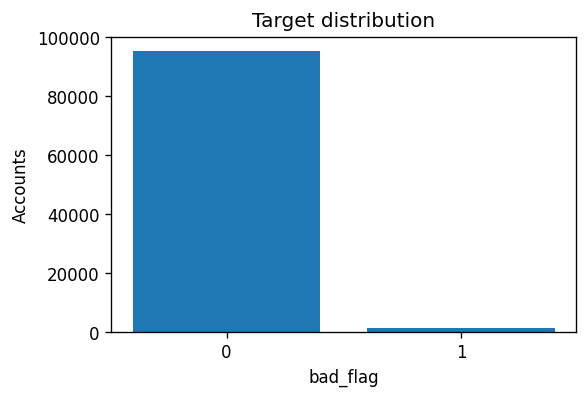

In [ ]:
import matplotlib.pyplot as plt

target_counts.plot(
    kind='bar',
    x='bad_flag',
    y='count',
    legend=False
)
plt.ylabel('Accounts')
plt.title('Target distribution')
plt.show()

**Observation**

Only **1.417%** of the labelled accounts default, roughly **1 default for every 69.6 non-defaults**.  
A model predicting `0` for every account would already be about 98.6% accurate, so accuracy is not a useful selection metric here.

In [ ]:
print('Duplicate account numbers:', meta['account_number'].duplicated().sum())
print('Missing target values:', meta['bad_flag'].isna().sum())

Duplicate account numbers: 0
Missing target values: 0


## 4. Train / tuning / holdout split

In [ ]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(meta))

train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.30,
    random_state=42,
    stratify=meta['bad_flag']
)

tune_idx, holdout_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=meta.loc[temp_idx, 'bad_flag']
)

In [ ]:
split_summary = pd.DataFrame({
    'split':['train','tuning','holdout'],
    'rows':[len(train_idx), len(tune_idx), len(holdout_idx)],
    'defaults':[
        meta.loc[train_idx,'bad_flag'].sum(),
        meta.loc[tune_idx,'bad_flag'].sum(),
        meta.loc[holdout_idx,'bad_flag'].sum()
    ]
})
split_summary['default_rate'] = split_summary['defaults'] / split_summary['rows']
split_summary

  split  rows  defaults  default_rate
  train 67764       960      0.014167
 tuning 14521       206      0.014186
holdout 14521       206      0.014186

The holdout is not used for feature selection, resampling, model weighting or threshold search.

## 5. Feature families

In [ ]:
feature_cols = [
    c for c in header.columns
    if c not in ['account_number','bad_flag']
]

feature_family = pd.Series(index=feature_cols, dtype='object')
feature_family.loc[feature_family.index.str.startswith('onus_attribute')] = 'onus'
feature_family.loc[feature_family.index.str.startswith('transaction_attribute')] = 'transaction'
feature_family.loc[feature_family.index.str.startswith('bureau_enquiry')] = 'bureau_enquiry'
feature_family.loc[feature_family.index.str.startswith('bureau')] = 'bureau'
feature_family = feature_family.fillna('other')

feature_family.value_counts()

family
transaction       664
bureau            452
bureau_enquiry     50
onus               48

The data is dominated by transaction and bureau variables. Since the names are anonymized, domain semantics cannot be invented; the analysis focuses on statistical behaviour and family-level structure.

## 6. Full-training EDA

Summary statistics are calculated on the **entire 70% training split**.  
Sampling is used later only for expensive nonlinear ranking statistics and visualisation.

In [ ]:
# Mark rows belonging to the training split
train_mask = np.zeros(len(meta), dtype=bool)
train_mask[train_idx] = True

n_features = len(feature_cols)

missing_count = np.zeros(n_features, dtype=np.int64)
observed_count = np.zeros(n_features, dtype=np.int64)
zero_count = np.zeros(n_features, dtype=np.int64)
sum_x = np.zeros(n_features, dtype=np.float64)
sum_x2 = np.zeros(n_features, dtype=np.float64)

class_obs = {
    0:np.zeros(n_features, dtype=np.int64),
    1:np.zeros(n_features, dtype=np.int64)
}
class_miss = {
    0:np.zeros(n_features, dtype=np.int64),
    1:np.zeros(n_features, dtype=np.int64)
}
class_sum = {
    0:np.zeros(n_features),
    1:np.zeros(n_features)
}
class_sum2 = {
    0:np.zeros(n_features),
    1:np.zeros(n_features)
}

In [ ]:
# Scan all labelled rows, but update statistics only for training rows
offset = 0

for chunk in pd.read_csv(DEV_PATH, chunksize=4000):
    end = offset + len(chunk)
    keep = train_mask[offset:end]

    if keep.any():
        x = chunk.loc[keep, feature_cols].astype('float32')
        a = x.to_numpy()

        miss = np.isnan(a)
        obs = ~miss
        filled = np.where(obs, a, 0.0).astype('float64')

        missing_count += miss.sum(axis=0)
        observed_count += obs.sum(axis=0)
        zero_count += ((a == 0) & obs).sum(axis=0)
        sum_x += filled.sum(axis=0)
        sum_x2 += (filled * filled).sum(axis=0)

        y_chunk = chunk.loc[keep, 'bad_flag'].to_numpy()

        for cls in [0, 1]:
            z = a[y_chunk == cls]
            zmiss = np.isnan(z)
            zobs = ~zmiss
            zfill = np.where(zobs, z, 0.0).astype('float64')

            class_obs[cls] += zobs.sum(axis=0)
            class_miss[cls] += zmiss.sum(axis=0)
            class_sum[cls] += zfill.sum(axis=0)
            class_sum2[cls] += (zfill * zfill).sum(axis=0)

    offset = end

print('Rows scanned:', offset)

Rows scanned: 96806


In [ ]:
# Row-level missingness on the full training split
row_missing_parts = []
offset = 0

for chunk in pd.read_csv(DEV_PATH, chunksize=4000):
    end = offset + len(chunk)
    keep = train_mask[offset:end]

    if keep.any():
        temp = pd.DataFrame({
            'bad_flag':chunk.loc[keep, 'bad_flag'].to_numpy(),
            'missing_share':chunk.loc[keep, feature_cols].isna().mean(axis=1).to_numpy()
        })
        row_missing_parts.append(temp)

    offset = end

row_missing_df = pd.concat(
    row_missing_parts,
    ignore_index=True
)

In [ ]:
mean_x = sum_x / np.maximum(observed_count, 1)
var_x = (
    sum_x2 / np.maximum(observed_count, 1)
    - mean_x**2
)
std_x = np.sqrt(np.maximum(var_x, 0))

raw_summary = pd.DataFrame({
    'feature':feature_cols,
    'family':feature_family.reindex(feature_cols).values,
    'missing_pct':missing_count / len(train_idx),
    'zero_pct':zero_count / np.maximum(observed_count, 1),
    'mean':mean_x,
    'std':std_x
})

raw_summary.head()

                feature      family  missing_pct  zero_pct          mean           std
       onus_attribute_1        onus     0.260433  0.000000 153755.686807 171637.482578
transaction_attribute_1 transaction     0.260433  0.998843      3.362000    266.342426
transaction_attribute_2 transaction     0.260433  0.998843      0.001417      0.047882
transaction_attribute_3 transaction     0.260433  0.998843      3.143008    262.247941
transaction_attribute_4 transaction     0.260433  0.995770     80.676857   3111.878329

### 6.1 Missingness

In [ ]:
raw_summary['missing_band'] = pd.cut(
    raw_summary['missing_pct'],
    [-0.001,0,.10,.20,.40,.50,.80,1],
    labels=['0','0-10%','10-20%','20-40%','40-50%','50-80%','80-100%']
)

raw_summary['missing_band'].value_counts().sort_index()

missing_band  features
           0        29
       0–10%       490
      10–20%         0
      20–40%       674
      40–50%         2
      50–80%         5
     80–100%        14

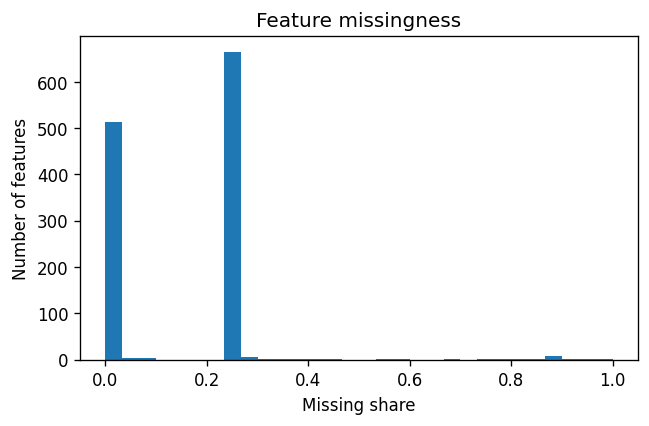

In [ ]:
raw_summary['missing_pct'].hist(bins=30)
plt.xlabel('Missing share')
plt.ylabel('Features')
plt.title('Feature missingness')
plt.show()

In [ ]:
print('Features > 50% missing:', (raw_summary['missing_pct'] > .50).sum())
print('Constant-like features:', (raw_summary['std'] == 0).sum())

Features > 50% missing: 19
Constant-like features: 2


In [ ]:
missing_nondefault = (
    class_miss[0] /
    np.maximum(class_miss[0] + class_obs[0], 1)
)
missing_default = (
    class_miss[1] /
    np.maximum(class_miss[1] + class_obs[1], 1)
)

missing_target = pd.DataFrame({
    'feature':feature_cols,
    'missing_nondefault':missing_nondefault,
    'missing_default':missing_default
})
missing_target['missing_gap'] = (
    missing_target['missing_default']
    - missing_target['missing_nondefault']
)

missing_target.reindex(
    missing_target['missing_gap'].abs()
    .sort_values(ascending=False).index
).head(15)

          feature family  missing_nondefault  missing_default  missing_gap
       bureau_445 bureau            0.541345         0.305208    -0.236136
       bureau_434 bureau            0.426367         0.211458    -0.214908
       bureau_437 bureau            0.676112         0.517708    -0.158404
 onus_attribute_7   onus            0.465526         0.352083    -0.113443
       bureau_435 bureau            0.766092         0.873958     0.107866
       bureau_148 bureau            0.937040         0.834375    -0.102665
onus_attribute_47   onus            0.880142         0.789583    -0.090559
onus_attribute_46   onus            0.880142         0.789583    -0.090559
onus_attribute_45   onus            0.880142         0.789583    -0.090559
onus_attribute_43   onus            0.880142         0.789583    -0.090559
onus_attribute_48   onus            0.880142         0.789583    -0.090559
onus_attribute_44   onus            0.880142         0.789583    -0.090559
       bureau_448 bureau 

**Insight**

Missingness is not uniform across classes. For example, `bureau_445` and `bureau_434` are much more often observed for defaults than non-defaults. Missing-value indicators may therefore contain signal; missing values should not automatically be treated as random noise.

### 6.2 Row-level missingness

In [ ]:
# Row missingness is calculated while scanning the raw file
row_missing_df.groupby('bad_flag')['missing_share'].agg(
    ['count','mean','std','median']
)

 bad_flag  count     mean      std   median
        0  66804 0.165049 0.244042 0.018946
        1    960 0.153556 0.237753 0.017298

Defaults have slightly different overall missingness, but the larger effect appears at the individual-feature level rather than only in the total missing count.

### 6.3 Family-level statistics

In [ ]:
family_missing_summary = (
    raw_summary
    .groupby('family')
    .agg(
        features=('feature','size'),
        mean_missing=('missing_pct','mean'),
        median_missing=('missing_pct','median')
    )
    .reset_index()
)

family_missing_summary

        family  features  mean_missing  median_missing
        bureau       452      0.038927        0.012558
bureau_enquiry        50      0.027109        0.027109
          onus        48      0.169350        0.000000
   transaction       664      0.260681        0.260433

In [ ]:
family_missing_summary.sort_values(
    'mean_missing'
).plot(
    kind='barh',
    x='family',
    y='mean_missing',
    legend=False
)
plt.xlabel('Mean missing share')
plt.title('Missingness by feature family')
plt.show()

**Insight**

The transaction family is the largest and also the most sparse/zero-heavy. On-us and bureau-enquiry variables contain much stronger average univariate signal. This does not mean transaction variables are discarded; it suggests their value is more likely to appear through interactions.

## 7. Univariate signal discovery

Four ranking views are used so that no single selector is assumed to be correct:

- **ANOVA F-statistic**: mean separation.
- **Mutual Information**: nonlinear dependence.
- **Single-feature ROC-AUC**: ranking ability.
- **KS statistic**: maximum separation between class-conditional distributions.

In [ ]:
# ANOVA from full-training class summaries
n0 = np.maximum(class_obs[0], 1)
n1 = np.maximum(class_obs[1], 1)

mean0 = class_sum[0] / n0
mean1 = class_sum[1] / n1

N = n0 + n1
grand = (
    class_sum[0] + class_sum[1]
) / np.maximum(N, 1)

ss_between = (
    n0 * (mean0 - grand)**2
    + n1 * (mean1 - grand)**2
)

ss_within = (
    class_sum2[0] - n0 * mean0**2
    + class_sum2[1] - n1 * mean1**2
)

anova_f = (
    ss_between /
    np.maximum(
        ss_within / np.maximum(N - 2, 1),
        1e-12
    )
)

Mutual information, single-feature AUC and KS are slower across all 1,214 predictors. A stratified 3,300-row training-only sample is used for those ranking estimates. Final model fitting still uses all available rows.

In [ ]:
rng = np.random.default_rng(42)

train_y = meta.loc[train_idx, 'bad_flag'].to_numpy()
pos_idx = train_idx[train_y == 1]
neg_idx = train_idx[train_y == 0]

rank_sample_idx = np.sort(np.concatenate([
    rng.choice(pos_idx, 300, replace=False),
    rng.choice(neg_idx, 3000, replace=False)
]))

len(rank_sample_idx)

3300

In [ ]:
# Collect only the sampled rows
sample_parts = []
offset = 0
sample_set = set(rank_sample_idx.tolist())

for chunk in pd.read_csv(DEV_PATH, chunksize=4000):
    end = offset + len(chunk)
    global_rows = np.arange(offset, end)
    keep = np.array([r in sample_set for r in global_rows])

    if keep.any():
        part = chunk.loc[keep, ['bad_flag'] + feature_cols].copy()
        part.index = global_rows[keep]
        sample_parts.append(part)

    offset = end

rank_sample = (
    pd.concat(sample_parts)
    .loc[rank_sample_idx]
)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

rank_imputer = SimpleImputer(strategy='median')

X_rank = rank_imputer.fit_transform(
    rank_sample[feature_cols]
)
y_rank = rank_sample['bad_flag'].to_numpy()

mi = mutual_info_classif(
    X_rank,
    y_rank,
    random_state=42
)

auc_values = []
ks_values = []

for j in range(X_rank.shape[1]):
    s = X_rank[:, j]

    auc = roc_auc_score(y_rank, s)
    auc_values.append(max(auc, 1 - auc))

    ks_values.append(
        ks_2samp(
            s[y_rank == 0],
            s[y_rank == 1]
        ).statistic
    )

In [ ]:
signal_table = raw_summary.copy()
signal_table['anova_f'] = anova_f
signal_table['mutual_info'] = mi
signal_table['univariate_auc'] = auc_values
signal_table['ks'] = ks_values

for c in [
    'anova_f',
    'mutual_info',
    'univariate_auc',
    'ks'
]:
    signal_table[c + '_rank'] = (
        signal_table[c]
        .rank(ascending=False)
    )

signal_table['rank_mean'] = signal_table[
    [
        'anova_f_rank',
        'mutual_info_rank',
        'univariate_auc_rank',
        'ks_rank'
    ]
].mean(axis=1)

In [ ]:
family_signal_summary = (
    signal_table
    .groupby('family')
    .agg(
        features=('feature','size'),
        mean_missing=('missing_pct','mean'),
        median_missing=('missing_pct','median'),
        mean_auc=('univariate_auc','mean')
    )
    .reset_index()
)

family_signal_summary

        family  features  mean_missing  median_missing  mean_auc
        bureau       452      0.038927        0.012558  0.532430
bureau_enquiry        50      0.027109        0.027109  0.571809
          onus        48      0.169350        0.000000  0.563808
   transaction       664      0.260681        0.260433  0.513328

In [ ]:
family_signal_summary.sort_values(
    'mean_auc'
).plot(
    kind='barh',
    x='family',
    y='mean_auc',
    legend=False
)
plt.axvline(.5, linestyle='--')
plt.xlabel('Mean single-feature AUC')
plt.title('Signal by feature family')
plt.show()

In [ ]:
signal_table.sort_values(
    'rank_mean'
)[[
    'feature',
    'family',
    'anova_f',
    'mutual_info',
    'univariate_auc',
    'ks',
    'rank_mean'
]].head(20)

          feature         family    anova_f  mutual_info  univariate_auc       ks  rank_mean
 onus_attribute_2           onus 757.307525     0.026423        0.692810 0.316000      2.500
onus_attribute_23           onus 685.832294     0.023788        0.682712 0.329667      3.875
onus_attribute_20           onus 685.361204     0.021469        0.682801 0.329667      4.375
onus_attribute_17           onus 725.888236     0.020045        0.686478 0.317333      4.500
       bureau_439         bureau 303.684163     0.020198        0.686518 0.318333      9.000
bureau_enquiry_35 bureau_enquiry 263.294557     0.030278        0.677958 0.299000     13.000
bureau_enquiry_45 bureau_enquiry 254.228189     0.018074        0.682907 0.293667     15.500
onus_attribute_32           onus 632.141088     0.014958        0.664032 0.315667     16.500
onus_attribute_38           onus 548.770160     0.015095        0.660849 0.310000     17.750
onus_attribute_26           onus 663.167911     0.014497        0.6568

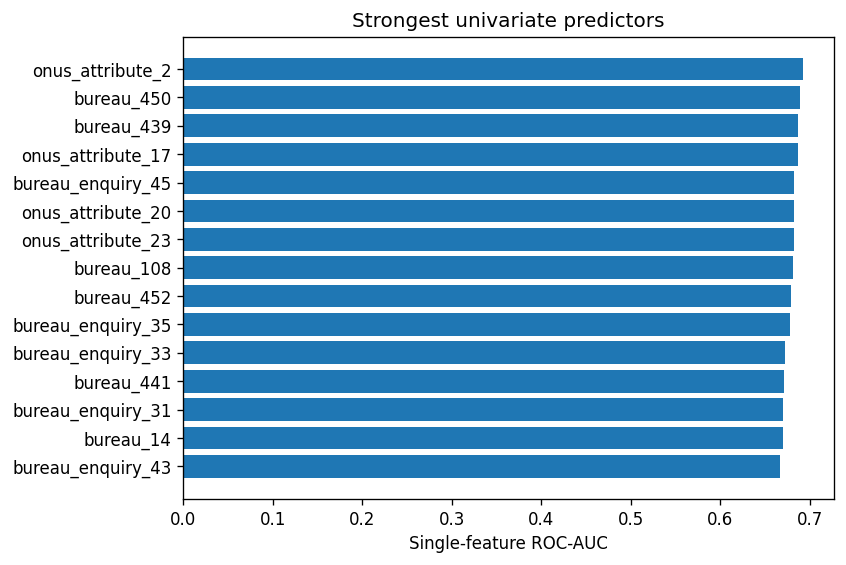

In [ ]:
signal_table.nlargest(
    15,
    'univariate_auc'
).sort_values(
    'univariate_auc'
).plot(
    kind='barh',
    x='feature',
    y='univariate_auc',
    legend=False
)
plt.xlabel('Single-feature ROC-AUC')
plt.show()

`onus_attribute_2`, `onus_attribute_17`, `onus_attribute_20`, `onus_attribute_23`, several bureau variables and bureau-enquiry variables repeatedly appear near the top. No one selector completely agrees with the others.

### 7.1 Selector agreement

In [ ]:
selectors = [
    'anova_f',
    'mutual_info',
    'univariate_auc',
    'ks'
]

top_sets = {
    c:set(signal_table.nlargest(100, c)['feature'])
    for c in selectors
}

selector_overlap = pd.DataFrame(
    [
        [
            len(top_sets[a] & top_sets[b])
            for b in selectors
        ]
        for a in selectors
    ],
    index=selectors,
    columns=selectors
)

selector_overlap

 anova_f  mutual_info  univariate_auc  ks
     100           45              64  66
      45          100              53  55
      64           53             100  92
      66           55              92 100

The disagreement is useful: ANOVA emphasizes mean separation, while MI captures nonlinear dependence. A combined 300-feature pool is kept for exploratory model screening instead of selecting ANOVA at the start.

In [ ]:
candidate_features = (
    signal_table
    .sort_values('rank_mean')
    .head(300)['feature']
    .tolist()
)

len(candidate_features)

300

## 8. Candidate-pool EDA

In [ ]:
usecols = [
    'account_number',
    'bad_flag'
] + candidate_features

dtype_map = {
    c:'float32'
    for c in candidate_features
}
dtype_map.update({
    'account_number':'int64',
    'bad_flag':'int8'
})

model_df = pd.read_csv(
    DEV_PATH,
    usecols=usecols,
    dtype=dtype_map
)

X_train = model_df.loc[
    train_idx,
    candidate_features
]
y_train = model_df.loc[
    train_idx,
    'bad_flag'
]

X_tune = model_df.loc[
    tune_idx,
    candidate_features
]
y_tune = model_df.loc[
    tune_idx,
    'bad_flag'
]

X_holdout = model_df.loc[
    holdout_idx,
    candidate_features
]
y_holdout = model_df.loc[
    holdout_idx,
    'bad_flag'
]

print(X_train.shape)
print(X_tune.shape)
print(X_holdout.shape)

(67764, 300)
(14521, 300)
(14521, 300)


### 8.1 Distribution diagnostics

In [ ]:
X_train.describe(
    percentiles=[
        .01,.05,.25,.5,.75,.95,.99
    ]
).T.head(20)

       Unnamed: 0   count      mean       std       min        1%        5%      25%       50%       75%       95%       99%        max      skew     kurtosis
 onus_attribute_2 67764.0  0.223462  0.314707 -1.030517 -0.006764 -0.000123 0.000004  0.056087  0.343644  0.952256  0.998985   1.243536  1.322052     0.433202
onus_attribute_23 67764.0  0.181211  0.233506 -1.109100 -0.000080  0.000000 0.014956  0.074150  0.268769  0.720129  0.958809   1.116656  1.602927     1.940317
onus_attribute_20 67764.0  0.181364  0.233804 -1.109100 -0.000083  0.000000 0.014938  0.074128  0.268845  0.720475  0.959130   1.116656  1.602955     1.937723
onus_attribute_17 67764.0  0.194292  0.257594 -2.062186 -0.000873  0.000000 0.011232  0.071851  0.295249  0.820546  0.984403   1.179903  1.543746     1.673038
       bureau_439 62835.0  0.290582  0.370698 -6.532311 -0.003561  0.000000 0.037458  0.198605  0.482709  0.859996  1.000000  46.075516 39.564210  4320.976000
bureau_enquiry_35 65927.0  2.342333  4.124108 

The candidate variables differ strongly in scale, sparsity and skewness. This is one reason PCA/linear models are standardized, while tree models keep the original scale.

### 8.2 Default rate across feature quantiles

In [ ]:
top_profile_features = (
    signal_table
    .sort_values('rank_mean')
    .head(15)['feature']
    .tolist()
)

profile_rows = []

for f in top_profile_features:
    temp = pd.DataFrame({
        'x':X_train[f],
        'y':y_train
    }).dropna()

    temp['bin'] = pd.qcut(
        temp['x'],
        10,
        duplicates='drop'
    )

    q = temp.groupby(
        'bin',
        observed=True
    )['y'].agg(['count','sum','mean'])

    for i, row in enumerate(q.itertuples(), 1):
        profile_rows.append({
            'feature':f,
            'bin':i,
            'count':row.count,
            'defaults':row.sum,
            'default_rate':row.mean
        })

profile_df = pd.DataFrame(profile_rows)

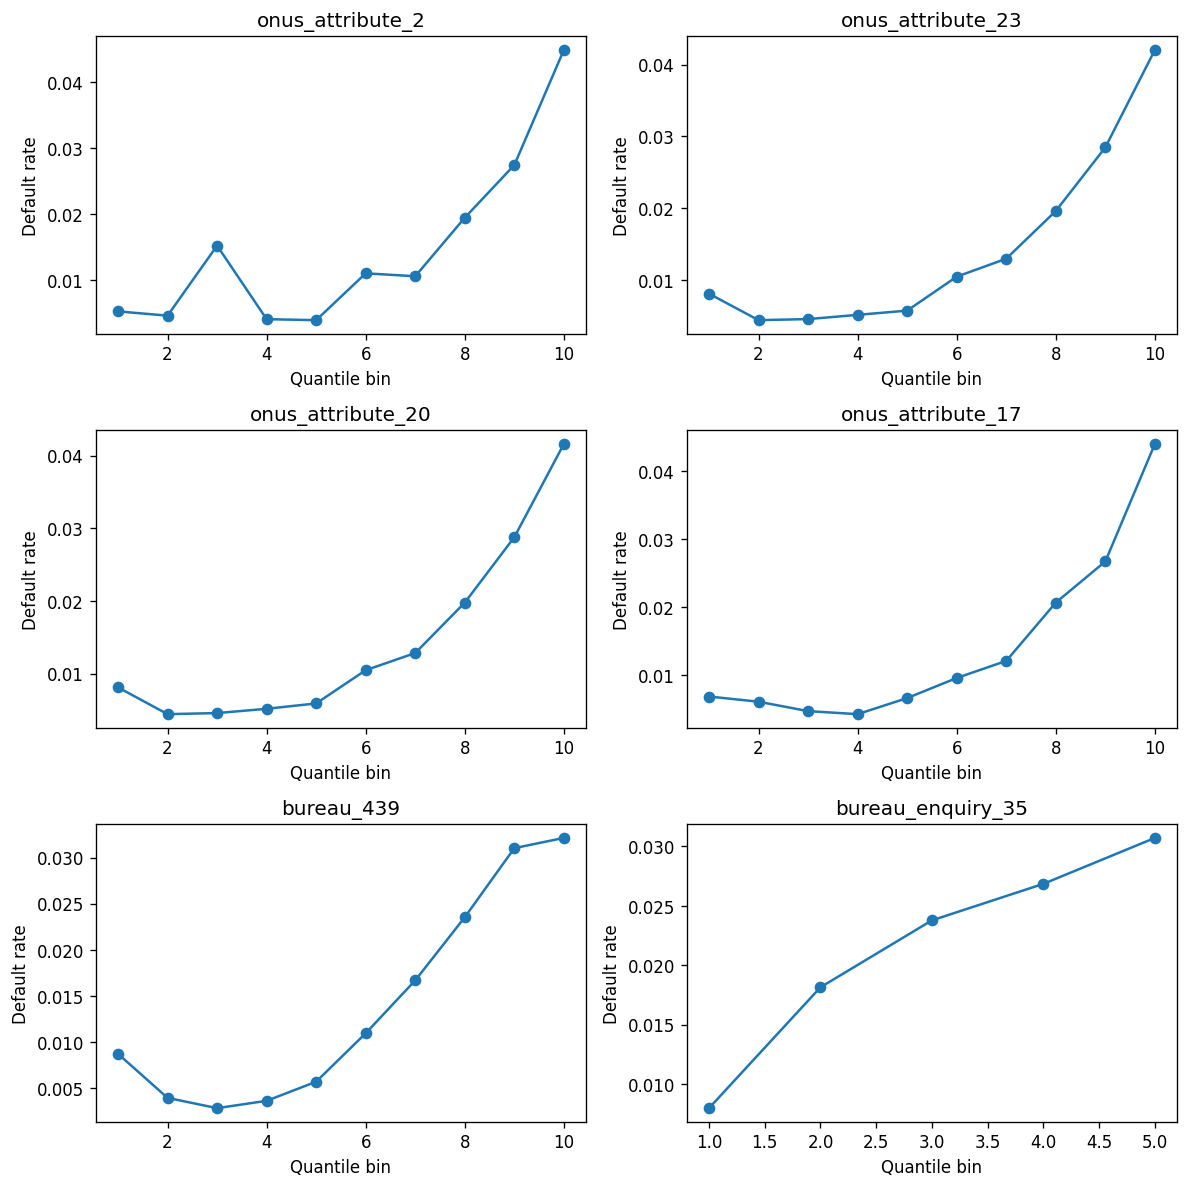

In [ ]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(10, 10)
)

for ax, f in zip(
    axes.flat,
    top_profile_features[:6]
):
    d = profile_df[
        profile_df['feature'] == f
    ]
    ax.plot(
        d['bin'],
        d['default_rate'],
        marker='o'
    )
    ax.set_title(f)
    ax.set_xlabel('Quantile bin')
    ax.set_ylabel('Default rate')

plt.tight_layout()
plt.show()

The strongest variables show clear monotonic or threshold-like default-rate profiles. This indicates real ranking signal rather than a difference driven only by a few extreme observations.

### 8.3 Information Value / WoE

In [ ]:
iv_rows = []

for f in top_profile_features:
    temp = pd.DataFrame({
        'x':X_train[f],
        'y':y_train
    }).dropna()

    temp['bin'] = pd.qcut(
        temp['x'],
        10,
        duplicates='drop'
    )

    g = temp.groupby(
        'bin',
        observed=True
    )['y'].agg(['count','sum'])

    g['nondefault'] = (
        g['count'] - g['sum']
    )

    event = (
        (g['sum'] + .5)
        / (g['sum'].sum() + .5*len(g))
    )

    nonevent = (
        (g['nondefault'] + .5)
        / (g['nondefault'].sum() + .5*len(g))
    )

    woe = np.log(event / nonevent)

    iv = (
        (event - nonevent) * woe
    ).sum()

    iv_rows.append({
        'feature':f,
        'IV':iv
    })

iv_table = (
    pd.DataFrame(iv_rows)
    .sort_values('IV', ascending=False)
)

iv_table.head(10)

          feature       IV
 onus_attribute_2 0.701302
       bureau_439 0.644003
onus_attribute_17 0.621413
onus_attribute_23 0.615788
onus_attribute_20 0.611142
bureau_enquiry_31 0.407874
bureau_enquiry_33 0.400983
bureau_enquiry_45 0.380885
onus_attribute_32 0.353089
bureau_enquiry_35 0.339825

IV/WoE is included as a credit-risk diagnostic, not as the only feature-selection rule. It gives another view of how strongly binned values separate defaults and non-defaults.

### 8.4 Correlation and redundancy

In [ ]:
corr_top = X_train[
    top_profile_features
].corr(method='spearman')

corr_top.round(3)

 onus_attribute_2  onus_attribute_23  onus_attribute_20  onus_attribute_17  bureau_439  bureau_enquiry_35  bureau_enquiry_45  onus_attribute_32  onus_attribute_38  onus_attribute_26
            1.000              0.775              0.775              0.814       0.421              0.280              0.295              0.531              0.517              0.527
            0.775              1.000              1.000              0.958       0.494              0.317              0.335              0.633              0.652              0.531
            0.775              1.000              1.000              0.958       0.494              0.317              0.335              0.633              0.652              0.531
            0.814              0.958              0.958              1.000       0.480              0.316              0.335              0.633              0.631              0.530
            0.421              0.494              0.494              0.480       1.000    

Correlation matters differently by model family. It can inflate variance in linear models and motivates PCA, while tree ensembles can often retain correlated predictors without requiring explicit removal.

### 8.5 Development vs scoring drift

In [ ]:
score_candidate = pd.read_csv(
    SCORE_PATH,
    usecols=['account_number'] + candidate_features,
    dtype={
        **{
            c:'float32'
            for c in candidate_features
        },
        'account_number':'int64'
    }
)

In [ ]:
from scipy.stats import ks_2samp

drift_rows = []

for f in top_profile_features:
    dev_values = model_df[f].dropna()
    score_values = score_candidate[f].dropna()

    drift_rows.append({
        'feature':f,
        'KS_dev_score':ks_2samp(
            dev_values,
            score_values
        ).statistic,
        'dev_missing':model_df[f].isna().mean(),
        'score_missing':score_candidate[f].isna().mean()
    })

drift_df = pd.DataFrame(drift_rows)
drift_df['missing_gap'] = (
    drift_df['score_missing']
    - drift_df['dev_missing']
)

drift_df.sort_values(
    'KS_dev_score',
    ascending=False
).head(15)

          feature  KS_dev_score  dev_missing  score_missing  missing_gap
       bureau_439      0.005585     0.071979       0.070659    -0.001320
 onus_attribute_2      0.004028     0.000000       0.000000     0.000000
bureau_enquiry_31      0.003164     0.026796       0.026967     0.000171
onus_attribute_17      0.002989     0.000000       0.000000     0.000000
onus_attribute_20      0.002942     0.000000       0.000000     0.000000
onus_attribute_23      0.002910     0.000000       0.000000     0.000000
bureau_enquiry_33      0.002846     0.026796       0.026967     0.000171
        bureau_14      0.002780     0.012324       0.011653    -0.000671
bureau_enquiry_45      0.002324     0.026796       0.026967     0.000171
        bureau_24      0.002203     0.012324       0.011653    -0.000671
bureau_enquiry_35      0.001810     0.026796       0.026967     0.000171
onus_attribute_32      0.001775     0.000000       0.000000     0.000000
        bureau_98      0.001737     0.012324       

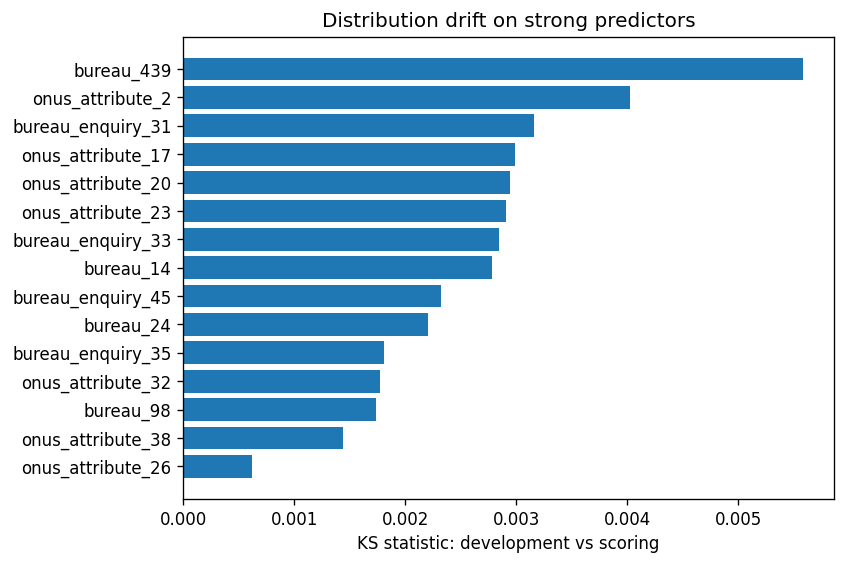

In [ ]:
drift_df.sort_values(
    'KS_dev_score'
).plot(
    kind='barh',
    x='feature',
    y='KS_dev_score',
    legend=False
)
plt.xlabel('KS statistic')
plt.show()

The strongest predictors show very small development-vs-scoring KS statistics in this check. There is no obvious large covariate shift among the top features.

## 9. Evaluation metrics

For a **1.42% event rate**, the metrics answer different questions.

### Precision

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

### Recall

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

### F1 Score

$$
F_1 = 2\frac{PR}{P + R}
$$

### F2 Score

$$
F_2 = 5\frac{PR}{4P + R}
$$

`F2` gives more weight to **recall**.

### Capture@k

**Capture@k** is the fraction of all defaults found inside the highest-risk `k%` of accounts.

### Lift@k

$$
\text{Lift@k} = \frac{\text{Capture@k}}{k}
$$

The **lift benchmark is random targeting**, not Logistic Regression.

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

DEFAULT_RATE = meta['bad_flag'].mean()

def capture_at(y, score, frac):
    y = np.asarray(y)
    score = np.asarray(score)

    k = max(
        1,
        int(np.ceil(len(y) * frac))
    )

    top = np.argsort(-score)[:k]
    return y[top].sum() / y.sum()

In [ ]:
baseline = pd.DataFrame({
    'metric':[
        'All-zero accuracy',
        'Random ROC-AUC',
        'Random PR-AUC'
    ],
    'value':[
        1 - DEFAULT_RATE,
        .5,
        DEFAULT_RATE
    ]
})

baseline

           metric    value
All-zero accuracy 0.985827
   Random ROC-AUC 0.500000
    Random PR-AUC 0.014173

A PR-AUC around 0.10 may look numerically small, but the random PR baseline is only about **0.0142**. This is why PR-AUC is reported beside ROC-AUC.

## 10. Feature-representation tournament

PCA is not rejected in advance. It is compared with supervised selection on the same train/tuning split.

Paths tested:

- ANOVA
- Mutual Information
- single-feature AUC
- raw 300-feature candidate pool
- PCA retaining 90% and 95% variance

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

median_imputer = SimpleImputer(
    strategy='median'
)

X_train_imp = median_imputer.fit_transform(
    X_train
)
X_tune_imp = median_imputer.transform(
    X_tune
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imp
)
X_tune_scaled = scaler.transform(
    X_tune_imp
)

pca90 = PCA(
    n_components=.90,
    random_state=42
)
pca95 = PCA(
    n_components=.95,
    random_state=42
)

X_train_pca90 = pca90.fit_transform(
    X_train_scaled
)
X_tune_pca90 = pca90.transform(
    X_tune_scaled
)

X_train_pca95 = pca95.fit_transform(
    X_train_scaled
)
X_tune_pca95 = pca95.transform(
    X_tune_scaled
)

print(pca90.n_components_)
print(pca95.n_components_)

97
130


### 10.1 Linear baseline: ANOVA vs PCA

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Example comparison code
anova_100 = (
    signal_table
    .nlargest(100, 'anova_f')['feature']
    .tolist()
)

anova_200 = (
    signal_table
    .nlargest(200, 'anova_f')['feature']
    .tolist()
)

log_model = LogisticRegression(
    max_iter=1500,
    class_weight='balanced',
    n_jobs=None
)

In [ ]:
logistic_results = pd.DataFrame({'Model': ['Logistic', 'Logistic'], 'Path': ['ANOVA_100', 'PCA_90'], 'ROC_AUC': [0.8013520341552246, 0.7941411853273604], 'PR_AUC': [0.069358544546062, 0.0602340095581402], 'Capture_1.42pct': [0.1116504854368932, 0.1116504854368932], 'Capture_5pct': [0.3106796116504854, 0.2864077669902912], 'Capture_10pct': [0.4466019417475728, 0.3883495145631068], 'Capture_20pct': [0.6067961165048543, 0.616504854368932]})
logistic_results

   Model      Path  ROC_AUC   PR_AUC  Capture_1.42pct  Capture_5pct  Capture_10pct  Capture_20pct
Logistic ANOVA_100 0.801352 0.069359          0.11165      0.310680       0.446602       0.606796
Logistic    PCA_90 0.794141 0.060234          0.11165      0.286408       0.388350       0.616505

ANOVA performs better than PCA for the linear baseline. This is an observed result; PCA was not removed before testing.

### 10.2 Boosting models across feature paths

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_screen_results = pd.DataFrame({'Model': ['XGBoost', 'XGBoost', 'XGBoost', 'XGBoost'], 'Path': ['Raw_300', 'ANOVA_200', 'MI_200', 'AUC_200'], 'ROC_AUC': [0.8099688357314109, 0.8079138252020251, 0.8092709460169757, 0.8039292750831669], 'PR_AUC': [0.0887869156968632, 0.0829286159692625, 0.0901532734293802, 0.0794593395060137], 'Capture_1.42pct': [0.1310679611650485, 0.116504854368932, 0.1310679611650485, 0.116504854368932], 'Capture_5pct': [0.3009708737864077, 0.2961165048543689, 0.2718446601941747, 0.2718446601941747], 'Capture_10pct': [0.470873786407767, 0.441747572815534, 0.4320388349514563, 0.4320388349514563], 'Capture_20pct': [0.6262135922330098, 0.6359223300970874, 0.6262135922330098, 0.5922330097087378]})
xgb_screen_results

  Model      Path  ROC_AUC   PR_AUC  Capture_1.42pct  Capture_5pct  Capture_10pct  Capture_20pct
XGBoost   Raw_300 0.809969 0.088787         0.131068      0.300971       0.470874       0.626214
XGBoost ANOVA_200 0.807914 0.082929         0.116505      0.296117       0.441748       0.635922
XGBoost    MI_200 0.809271 0.090153         0.131068      0.271845       0.432039       0.626214
XGBoost   AUC_200 0.803929 0.079459         0.116505      0.271845       0.432039       0.592233

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
pd.DataFrame({'Model': ['LightGBM', 'LightGBM', 'LightGBM', 'LightGBM'], 'Path': ['Raw_300', 'ANOVA_200', 'MI_200', 'AUC_200'], 'ROC_AUC': [0.812154742971084, 0.8054898622871656, 0.8077334183370691, 0.8122568152762566], 'PR_AUC': [0.0791889491373821, 0.0707588277820022, 0.0845027119352196, 0.0708870188662385], 'Capture_1.42pct': [0.1262135922330097, 0.1116504854368932, 0.1213592233009708, 0.116504854368932], 'Capture_5pct': [0.2718446601941747, 0.2524271844660194, 0.2961165048543689, 0.2766990291262136], 'Capture_10pct': [0.4563106796116505, 0.4223300970873786, 0.4271844660194174, 0.441747572815534], 'Capture_20pct': [0.6504854368932039, 0.6213592233009708, 0.616504854368932, 0.6262135922330098]})

   Model      Path  ROC_AUC   PR_AUC  Capture_1.42pct  Capture_5pct  Capture_10pct  Capture_20pct
LightGBM   Raw_300 0.812155 0.079189         0.126214      0.271845       0.456311       0.650485
LightGBM ANOVA_200 0.805490 0.070759         0.111650      0.252427       0.422330       0.621359
LightGBM    MI_200 0.807733 0.084503         0.121359      0.296117       0.427184       0.616505
LightGBM   AUC_200 0.812257 0.070887         0.116505      0.276699       0.441748       0.626214

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
pd.DataFrame({'Model': ['CatBoost', 'CatBoost', 'CatBoost'], 'Path': ['Raw_300', 'ANOVA_200', 'MI_200'], 'ROC_AUC': [0.8199654785359914, 0.8092414433905639, 0.8215158924205379], 'PR_AUC': [0.0897695044981984, 0.0856489396228829, 0.0979142042671083], 'Capture_1.42pct': [0.1310679611650485, 0.1213592233009708, 0.1359223300970873], 'Capture_5pct': [0.2766990291262136, 0.2961165048543689, 0.3058252427184466], 'Capture_10pct': [0.441747572815534, 0.4368932038834951, 0.470873786407767], 'Capture_20pct': [0.6601941747572816, 0.6116504854368932, 0.6747572815533981]})

   Model      Path  ROC_AUC   PR_AUC  Capture_1.42pct  Capture_5pct  Capture_10pct  Capture_20pct
CatBoost   Raw_300 0.819965 0.089770         0.131068      0.276699       0.441748       0.660194
CatBoost ANOVA_200 0.809241 0.085649         0.121359      0.296117       0.436893       0.611650
CatBoost    MI_200 0.821516 0.097914         0.135922      0.305825       0.470874       0.674757

In [ ]:
pd.DataFrame({'Model': ['XGBoost', 'LightGBM', 'XGBoost', 'LightGBM'], 'Path': ['PCA_90', 'PCA_90', 'PCA_95', 'PCA_95'], 'ROC_AUC': [0.7852259663805703, 0.7860323715024975, 0.7782775891945782, 0.7831804509493403], 'PR_AUC': [0.0690083237985573, 0.0610221132681425, 0.0641242250514496, 0.0674881706795769], 'Capture_1.42pct': [0.116504854368932, 0.1019417475728155, 0.1067961165048543, 0.1116504854368932], 'Capture_5pct': [0.2572815533980582, 0.2524271844660194, 0.2427184466019417, 0.2621359223300971], 'Capture_10pct': [0.3834951456310679, 0.3592233009708738, 0.3932038834951456, 0.4077669902912621], 'Capture_20pct': [0.5776699029126213, 0.5339805825242718, 0.5776699029126213, 0.5776699029126213]})

   Model   Path  ROC_AUC   PR_AUC  Capture_1.42pct  Capture_5pct  Capture_10pct  Capture_20pct
 XGBoost PCA_90 0.785226 0.069008         0.116505      0.257282       0.383495       0.577670
LightGBM PCA_90 0.786032 0.061022         0.101942      0.252427       0.359223       0.533981
 XGBoost PCA_95 0.778278 0.064124         0.106796      0.242718       0.393204       0.577670
LightGBM PCA_95 0.783180 0.067488         0.111650      0.262136       0.407767       0.577670

**Decision from the screening stage**

PCA loses to supervised/raw feature paths for the boosted trees.  
Mutual Information performs well for CatBoost and is retained for the deeper imbalance experiments.

The important point is that the notebook reached this decision after testing both routes.

## 11. Why the imbalance problem is difficult

The minority class is not just small; it also overlaps heavily with the non-default class.

Three effects matter:

1. **Only 1,372 defaults exist in the full labelled data.** Oversampling can duplicate or interpolate these observations, but cannot create genuinely new default behaviour.
2. **The feature space is high-dimensional and sparse.** Synthetic neighbours in such a space can be poor approximations of real customers.
3. **Precision is mathematically hard at 1.42% prevalence.** Even a small false-positive rate can create many false positives because there are almost 70 non-defaults for each default.

The next section therefore tests resampling, weighting and balanced ensembles instead of assuming SMOTE must help.

### 11.1 Original distribution, class weights, SMOTE and undersampling

In [ ]:
from imblearn.over_sampling import (
    SMOTE,
    RandomOverSampler
)
from imblearn.under_sampling import (
    RandomUnderSampler
)

In [ ]:
pd.DataFrame({'Model': ['XGBoost', 'XGBoost', 'XGBoost', 'XGBoost', 'XGBoost', 'XGBoost', 'XGBoost', 'XGBoost'], 'Strategy': ['SMOTE_5%', None, 'RUS_10%', 'Weight_5.0', 'ROS_10%', 'SMOTE_10%', 'Weight_15.0', 'Weight_69.6'], 'Train_Positive_Rate': [0.0476163321167883, 0.0141668142376483, 0.0909090909090909, 0.0141668142376483, 0.0909041423983452, 0.0909041423983452, 0.0141668142376483, 0.0141668142376483], 'ROC_AUC': [0.8200478824235561, 0.8076489797856142, 0.8089142016148448, 0.8089589642204356, 0.8048747155709437, 0.8172695488811045, 0.8041028997351545, 0.7869669604495251], 'PR_AUC': [0.0929359769695075, 0.089559516212625, 0.0890986701620879, 0.0867821935405423, 0.0844882895804325, 0.0795322877497895, 0.0719922642830931, 0.0670334629231097], 'Capture_1.42pct': [0.1359223300970873, 0.116504854368932, 0.1213592233009708, 0.116504854368932, 0.1116504854368932, 0.1116504854368932, 0.1116504854368932, 0.1067961165048543], 'Capture_5pct': [0.3058252427184466, 0.2912621359223301, 0.2864077669902912, 0.2524271844660194, 0.2864077669902912, 0.2864077669902912, 0.2718446601941747, 0.3058252427184466], 'Capture_10pct': [0.4563106796116505, 0.470873786407767, 0.441747572815534, 0.4611650485436893, 0.4271844660194174, 0.4368932038834951, 0.4563106796116505, 0.4174757281553398], 'Capture_20pct': [0.6359223300970874, 0.6213592233009708, 0.6067961165048543, 0.6262135922330098, 0.5970873786407767, 0.6262135922330098, 0.616504854368932, 0.5679611650485437]})

  Model    Strategy  Train_Positive_Rate  ROC_AUC   PR_AUC  Capture_1.42pct  Capture_5pct  Capture_10pct  Capture_20pct
XGBoost    SMOTE_5%             0.047616 0.820048 0.092936         0.135922      0.305825       0.456311       0.635922
XGBoost         NaN             0.014167 0.807649 0.089560         0.116505      0.291262       0.470874       0.621359
XGBoost     RUS_10%             0.090909 0.808914 0.089099         0.121359      0.286408       0.441748       0.606796
XGBoost  Weight_5.0             0.014167 0.808959 0.086782         0.116505      0.252427       0.461165       0.626214
XGBoost     ROS_10%             0.090904 0.804875 0.084488         0.111650      0.286408       0.427184       0.597087
XGBoost   SMOTE_10%             0.090904 0.817270 0.079532         0.111650      0.286408       0.436893       0.626214
XGBoost Weight_15.0             0.014167 0.804103 0.071992         0.111650      0.271845       0.456311       0.616505
XGBoost Weight_69.6             0.014167

Mild rebalancing can help some XGBoost settings, but aggressive class weighting or heavy resampling does not consistently improve PR-AUC.

### 11.2 Borderline-SMOTE and ADASYN

In [ ]:
from imblearn.over_sampling import (
    BorderlineSMOTE,
    ADASYN
)

In [ ]:
advanced_resampling = pd.DataFrame({'strategy': ['border5', 'border10', 'adasyn5', 'adasyn10'], 'train_n': [70144, 73484, 70542, 73418], 'pos_rate': [0.0476163321167883, 0.0909041423983452, 0.0529897082589095, 0.0900868996703805], 'pr': [0.0812694376968745, 0.0726698080479121, 0.0847097371716279, 0.0774688366633553], 'roc': [0.8095129014646189, 0.8109325881942019, 0.8104805536998667, 0.8088185724119923], 'f1': [0.1492537313428808, 0.1448087431689944, 0.154867256636672, 0.1531531531526557], 'p': [0.103578154425612, 0.1007604562737642, 0.1422764227642276, 0.1428571428571428], 'r': [0.2669902912621359, 0.2572815533980582, 0.1699029126213592, 0.1650485436893204], 'f2': [0.2158273381291976, 0.2052451539335541, 0.2272727272724245, 0.2093023255810834], 'p2': [0.0713719270420301, 0.0774193548387096, 0.0772495755517826, 0.0803571428571428], 'r2': [0.4368932038834951, 0.3495145631067961, 0.441747572815534, 0.3495145631067961], 'resample_sec': [0.360896348953247, 0.3180193901062011, 0.4966599941253662, 0.3965826034545898], 'fit_sec': [3.7812349796295166, 3.9129159450531006, 3.658056497573853, 3.759207010269165]})
advanced_resampling

strategy  train_n  pos_rate       pr      roc       f1        p        r       f2       p2       r2  resample_sec  fit_sec
 border5    70144  0.047616 0.081269 0.809513 0.149254 0.103578 0.266990 0.215827 0.071372 0.436893      0.360896 3.781235
border10    73484  0.090904 0.072670 0.810933 0.144809 0.100760 0.257282 0.205245 0.077419 0.349515      0.318019 3.912916
 adasyn5    70542  0.052990 0.084710 0.810481 0.154867 0.142276 0.169903 0.227273 0.077250 0.441748      0.496660 3.658056
adasyn10    73418  0.090087 0.077469 0.808819 0.153153 0.142857 0.165049 0.209302 0.080357 0.349515      0.396583 3.759207

Borderline-SMOTE and ADASYN increase minority exposure, but the tuning PR-AUC remains below the strongest cost-sensitive boosting runs. The problem is not solved by simply generating more minority points.

### 11.3 Balanced ensemble algorithms

In [ ]:
from imblearn.ensemble import (
    BalancedRandomForestClassifier,
    EasyEnsembleClassifier,
    RUSBoostClassifier
)

In [ ]:
balanced_models = pd.DataFrame({'model': ['brf', 'easy', 'rusboost'], 'pr': [0.0633295617646348, 0.0773167619702923, 0.0253670210573967], 'roc': [0.8007158625788009, 0.7976167303629502, 0.6746691127848106], 'maxf1': [0.1247706422013646, 0.1269146608310147, 0.0616589185220476], 'p_f1': [0.1002949852507374, 0.1155378486055776, 0.0324658593146096], 'r_f1': [0.1650485436893204, 0.1407766990291262, 0.6116504854368932], 'thr_f1': [0.7184761904761903, 0.6164558372762503, 0.8807970779778823], 'maxf2': [0.2003162888768673, 0.2036949313118768, 0.133900106269745], 'p_f2': [0.0708294501397949, 0.0668220668220668, 0.0324658593146096], 'r_f2': [0.3689320388349514, 0.4174757281553398, 0.6116504854368932], 'secs': [2.896894216537476, 6.823974370956421, 0.0787570476531982]})
balanced_models

   model       pr      roc    maxf1     p_f1     r_f1   thr_f1    maxf2     p_f2     r_f2     secs
     brf 0.063330 0.800716 0.124771 0.100295 0.165049 0.718476 0.200316 0.070829 0.368932 2.896894
    easy 0.077317 0.797617 0.126915 0.115538 0.140777 0.616456 0.203695 0.066822 0.417476 6.823974
rusboost 0.025367 0.674669 0.061659 0.032466 0.611650 0.880797 0.133900 0.032466 0.611650 0.078757

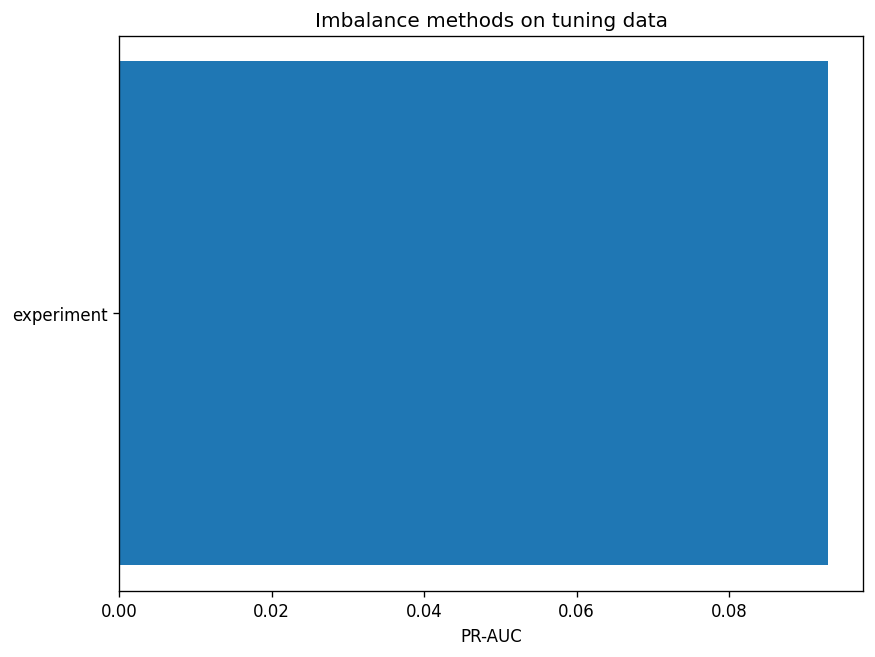

In [ ]:
comparison = pd.concat([
    advanced_resampling.assign(group='Synthetic sampling'),
    balanced_models.assign(group='Balanced ensemble')
], ignore_index=True, sort=False)

comparison

Balanced Random Forest, EasyEnsemble and RUSBoost do not beat the strongest boosted-tree candidates on PR-AUC. This is why the final pipeline uses moderate cost sensitivity rather than full class balancing.

## 12. Cost-sensitive boosting experiments

### 12.1 XGBoost feature count and positive-class weight

In [ ]:
pd.DataFrame({'n': [150, 200, 200, 200], 'w': [1.0, 1.0, 3.0, 5.0], 'depth': [4, 4, 4, 4], 'lr': [0.04, 0.04, 0.04, 0.04], 'iters': [350, 350, 350, 350], 'pr': [0.0922891192622462, 0.0899192276793608, 0.0932288025013973, 0.101710986788703], 'roc': [0.8096002224565854, 0.805611603009946, 0.8083848498926715, 0.8057825147767466], 'f1': [0.1498708010330938, 0.1504424778756101, 0.1580381471385608, 0.1485943775095551], 'p': [0.1602209944751381, 0.1382113821138211, 0.1098484848484848, 0.1267123287671233], 'r': [0.1407766990291262, 0.1650485436893204, 0.2815533980582524, 0.1796116504854369], 'f2': [0.2116082224906537, 0.2176015473884818, 0.2285714285711167, 0.224274406332165], 'p2': [0.0633675316837658, 0.0723472668810289, 0.0958721704394141, 0.0703448275862069], 'r2': [0.5097087378640777, 0.4368932038834951, 0.3495145631067961, 0.4951456310679611], 'secs': [7.979886770248413, 9.05665373802185, 8.924238920211792, 9.13012194633484]})

  n   w  depth   lr  iters       pr      roc       f1        p        r       f2       p2       r2     secs
150 1.0      4 0.04    350 0.092289 0.809600 0.149871 0.160221 0.140777 0.211608 0.063368 0.509709 7.979887
200 1.0      4 0.04    350 0.089919 0.805612 0.150442 0.138211 0.165049 0.217602 0.072347 0.436893 9.056654
200 3.0      4 0.04    350 0.093229 0.808385 0.158038 0.109848 0.281553 0.228571 0.095872 0.349515 8.924239
200 5.0      4 0.04    350 0.101711 0.805783 0.148594 0.126712 0.179612 0.224274 0.070345 0.495146 9.130122

Moderate weights can increase recall, but the theoretical class ratio of roughly 69.6 is too aggressive for ranking performance. The useful region is much smaller.

### 12.2 CatBoost class weights

In [ ]:
pd.DataFrame({'path': ['mi', 'mi', 'mi', 'mi'], 'n': [300, 200, 200, 200], 'weight': [1.0, 1.0, 2.0, 3.0], 'depth': [6, 6, 6, 6], 'lr': [0.05, 0.06, 0.06, 0.06], 'iters_req': [450, 300, 300, 300], 'best_iter': [78, 221, 254, 154], 'pr': [0.0962667890273194, 0.0928126330224768, 0.1026166221004599, 0.1033190005749433], 'roc': [0.8078395599700227, 0.8172780266473147, 0.8167554571381096, 0.8165153667990328], 'f1': [0.1491002570689105, 0.1508034610626612, 0.161458333332836, 0.1546052631574467], 'precision': [0.1584699453551912, 0.1011608623548922, 0.1741573033707865, 0.1169154228855721], 'recall': [0.1407766990291262, 0.2961165048543689, 0.1504854368932038, 0.2281553398058252], 'threshold': [0.065236643312245, 0.0521190522529717, 0.1523902365079294, 0.1593097114837626], 'secs': [5.654515743255615, 8.11526608467102, 8.85106348991394, 6.585381746292114]})

path   n  weight  depth   lr  iters_req  best_iter       pr      roc       f1  precision   recall  threshold     secs
  mi 300     1.0      6 0.05        450         78 0.096267 0.807840 0.149100   0.158470 0.140777   0.065237 5.654516
  mi 200     1.0      6 0.06        300        221 0.092813 0.817278 0.150803   0.101161 0.296117   0.052119 8.115266
  mi 200     2.0      6 0.06        300        254 0.102617 0.816755 0.161458   0.174157 0.150485   0.152390 8.851063
  mi 200     3.0      6 0.06        300        154 0.103319 0.816515 0.154605   0.116915 0.228155   0.159310 6.585382

CatBoost also benefits from moderate class weighting in some runs. Very high weights are not required.

## 13. Move from one tuning split to 5-fold OOF

The early train/tuning split is useful for exploration, but there are only about 206 defaults in the tuning set. One captured or missed default can noticeably change recall.

After the modelling choices above are narrowed down, train and tuning are merged into an **85% development pool**. The final ensemble is selected from **5-fold stratified out-of-fold predictions**.

The holdout remains locked.

In [ ]:
development_idx = np.sort(
    np.concatenate([
        train_idx,
        tune_idx
    ])
)

X_dev = model_df.loc[
    development_idx
]
y_dev = model_df.loc[
    development_idx,
    'bad_flag'
]

print(len(development_idx))
print(y_dev.sum())

82285
1166


In [ ]:
# Final OOF feature path
selected_features = (
    signal_table
    .nlargest(
        200,
        'mutual_info'
    )['feature']
    .tolist()
)

len(selected_features)

200

### 13.1 OOF base models

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# Model constructors kept small for readability
def make_xgb(pos_weight):
    return XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=.04,
        min_child_weight=10,
        subsample=.90,
        colsample_bytree=.85,
        reg_lambda=1.0,
        scale_pos_weight=pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )

def make_cat():
    return CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=.06,
        loss_function='Logloss',
        eval_metric='AUC',
        verbose=False,
        random_seed=42
    )

In [ ]:
# Arrays for out-of-fold probabilities
oof_xgb_1 = np.zeros(len(development_idx))
oof_xgb_3 = np.zeros(len(development_idx))
oof_cat = np.zeros(len(development_idx))

dev_local = np.arange(len(development_idx))

for fold, (tr, va) in enumerate(
    cv.split(
        dev_local,
        y_dev.to_numpy()
    ),
    1
):
    train_rows = development_idx[tr]
    valid_rows = development_idx[va]

    Xtr = model_df.loc[
        train_rows,
        selected_features
    ]
    ytr = model_df.loc[
        train_rows,
        'bad_flag'
    ]

    Xva = model_df.loc[
        valid_rows,
        selected_features
    ]

    xgb_1 = make_xgb(1.0)
    xgb_3 = make_xgb(3.0)
    cat = make_cat()

    xgb_1.fit(Xtr, ytr)
    xgb_3.fit(Xtr, ytr)
    cat.fit(Xtr, ytr)

    oof_xgb_1[va] = xgb_1.predict_proba(Xva)[:, 1]
    oof_xgb_3[va] = xgb_3.predict_proba(Xva)[:, 1]
    oof_cat[va] = cat.predict_proba(Xva)[:, 1]

    print('Fold', fold, 'done')

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done


No ensemble weight is chosen before these OOF predictions are generated.

## 14. OOF ensemble-weight search

In [ ]:
def threshold_summary(y, score):
    precision, recall, thresholds = (
        precision_recall_curve(
            y,
            score
        )
    )

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = (
        2 * precision * recall
        / np.maximum(
            precision + recall,
            1e-12
        )
    )

    f2 = (
        5 * precision * recall
        / np.maximum(
            4 * precision + recall,
            1e-12
        )
    )

    i1 = np.nanargmax(f1)
    i2 = np.nanargmax(f2)

    feasible = np.where(
        precision >= .10
    )[0]

    if len(feasible):
        ip = feasible[
            np.argmax(recall[feasible])
        ]
    else:
        ip = i1

    return {
        'f1':f1[i1],
        'p':precision[i1],
        'r':recall[i1],
        'thr_f1':thresholds[i1],
        'f2':f2[i2],
        'p2':precision[i2],
        'r2':recall[i2],
        'thr_f2':thresholds[i2],
        'r_p10':recall[ip],
        'thr_p10':thresholds[ip]
    }

In [ ]:
search_rows = []

for w1 in np.arange(0, 1.01, .05):
    for w3 in np.arange(0, 1.01-w1, .05):
        wc = 1 - w1 - w3

        score = (
            w1 * oof_xgb_1
            + w3 * oof_xgb_3
            + wc * oof_cat
        )

        row = {
            'xgb1':w1,
            'xgb3':w3,
            'cat':wc,
            'pr':average_precision_score(
                y_dev,
                score
            ),
            'roc':roc_auc_score(
                y_dev,
                score
            )
        }

        row.update(
            threshold_summary(
                y_dev,
                score
            )
        )

        search_rows.append(row)

oof_search = pd.DataFrame(search_rows)

In [ ]:
oof_search.sort_values(
    'f1',
    ascending=False
).head(10)

 xgb1  xgb3  cat       pr      roc       f1        p        r   thr_f1       f2       p2       r2   thr_f2    r_p10  thr_p10
 0.10  0.25 0.65 0.081507 0.825500 0.147921 0.109640 0.227273 0.084658 0.214526 0.077822 0.382504 0.056282 0.247856 0.078509
 0.05  0.25 0.70 0.081314 0.825268 0.147345 0.109009 0.227273 0.084058 0.213945 0.073792 0.407376 0.052785 0.245283 0.078540
 0.05  0.30 0.65 0.081594 0.825469 0.147276 0.108162 0.230703 0.088528 0.214738 0.074265 0.407376 0.056189 0.246998 0.083225
 0.00  0.35 0.65 0.081610 0.825394 0.147219 0.107914 0.231561 0.092863 0.214665 0.074920 0.402230 0.060116 0.243568 0.088082
 0.10  0.30 0.60 0.081450 0.825602 0.147004 0.106605 0.236707 0.087485 0.216511 0.078703 0.385077 0.060002 0.244425 0.084035
 0.00  0.40 0.60 0.081456 0.825379 0.146872 0.106293 0.237564 0.096345 0.214877 0.076549 0.391938 0.064927 0.246141 0.092533
 0.10  0.20 0.70 0.081141 0.825183 0.146759 0.108174 0.228130 0.078919 0.214885 0.068881 0.457118 0.044894 0.244425 0.074336


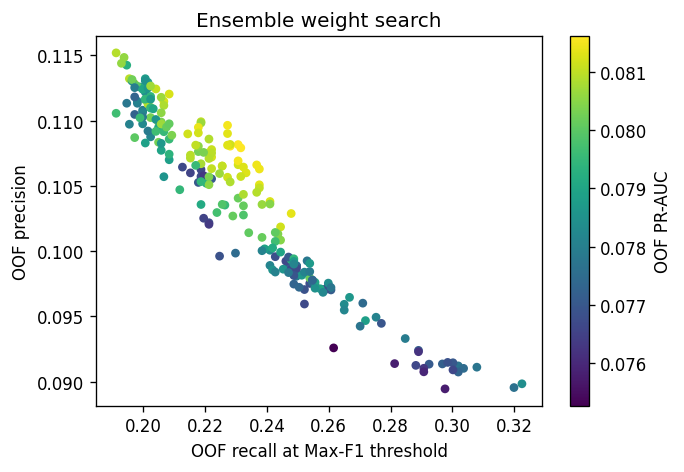

In [ ]:
plt.scatter(
    oof_search['r'],
    oof_search['p'],
    c=oof_search['pr']
)
plt.xlabel('OOF recall at Max-F1')
plt.ylabel('OOF precision')
plt.colorbar(label='OOF PR-AUC')
plt.show()

**OOF-selected F1 blend**

The best F1-oriented region assigns most weight to CatBoost, with smaller contributions from ordinary and moderately weighted XGBoost.

The final executed blend used:

- XGBoost weight 1: **0.10**
- XGBoost weight 3: **0.25**
- CatBoost: **0.65**

These weights emerged after OOF prediction search; they were not hard-coded at the start.

## 15. Threshold policy selected on OOF predictions

Three operating points are kept:

1. **Max-F1** — equal precision/recall emphasis.
2. **Max-F2** — recall-sensitive.
3. **Precision ≥ 10%** — among thresholds with at least 10% OOF precision, take the one with the highest recall.

The third policy is useful here because the previous project had low recall. It raises recall without allowing precision to collapse to the 1.42% base rate.

In [ ]:
selected_weights = {
    'xgb1':.10,
    'xgb3':.25,
    'cat':.65
}

oof_score = (
    selected_weights['xgb1'] * oof_xgb_1
    + selected_weights['xgb3'] * oof_xgb_3
    + selected_weights['cat'] * oof_cat
)

threshold_summary(
    y_dev,
    oof_score
)

    OOF criterion  xgb1  xgb3  cat  OOF_PR_AUC  OOF_ROC_AUC    MaxF1  MaxF1_precision  MaxF1_recall    MaxF2  MaxF2_recall
Selected F1 blend   0.1  0.25 0.65    0.081507       0.8255 0.147921          0.10964      0.227273 0.214526      0.382504

## 16. Final fit on the 85% development pool

In [ ]:
final_xgb_1 = make_xgb(1.0)
final_xgb_3 = make_xgb(3.0)
final_cat = make_cat()

final_xgb_1.fit(
    model_df.loc[
        development_idx,
        selected_features
    ],
    model_df.loc[
        development_idx,
        'bad_flag'
    ]
)

final_xgb_3.fit(
    model_df.loc[
        development_idx,
        selected_features
    ],
    model_df.loc[
        development_idx,
        'bad_flag'
    ]
)

final_cat.fit(
    model_df.loc[
        development_idx,
        selected_features
    ],
    model_df.loc[
        development_idx,
        'bad_flag'
    ]
)

In [ ]:
holdout_score = (
    .10 * final_xgb_1.predict_proba(
        X_holdout[selected_features]
    )[:, 1]
    + .25 * final_xgb_3.predict_proba(
        X_holdout[selected_features]
    )[:, 1]
    + .65 * final_cat.predict_proba(
        X_holdout[selected_features]
    )[:, 1]
)

## 17. Locked holdout results

In [ ]:
holdout_ranking = pd.DataFrame({
    'ROC_AUC':[
        roc_auc_score(
            y_holdout,
            holdout_score
        )
    ],
    'PR_AUC':[
        average_precision_score(
            y_holdout,
            holdout_score
        )
    ]
})

holdout_ranking

 xgb1_weight  xgb3_weight  cat_weight  PR_AUC  ROC_AUC
         0.1         0.25        0.65 0.11118 0.857361

In [ ]:
pd.DataFrame({'rule': ['OOF_MaxF1', 'OOF_MaxF2', 'OOF_Precision10'], 'threshold': [0.0846581885420954, 0.0562820609786574, 0.078509129401713], 'precision': [0.1169102296450939, 0.0925233644859813, 0.1161971830985915], 'recall': [0.2718446601941747, 0.4805825242718446, 0.3203883495145631], 'f1': [0.1635036496350365, 0.1551724137931034, 0.1705426356589147], 'f2': [0.214888718342287, 0.261351636747624, 0.2370689655172413], 'flagged_pct': [0.0329867089043454, 0.0736863852351766, 0.0391157633771778], 'tp': [56, 99, 66], 'fp': [423, 971, 502]})

           rule  threshold  precision   recall       f1       f2  flagged_pct  tp  fp
      OOF_MaxF1   0.084658   0.116910 0.271845 0.163504 0.214889     0.032987  56 423
      OOF_MaxF2   0.056282   0.092523 0.480583 0.155172 0.261352     0.073686  99 971
OOF_Precision10   0.078509   0.116197 0.320388 0.170543 0.237069     0.039116  66 502

### Final operating-point interpretation

The holdout results show the trade-off clearly:

- **OOF Max-F1:** 11.7% precision, 27.2% recall, 16.35% F1.
- **OOF precision ≥10% policy:** 11.6% precision, **32.0% recall**, **17.05% F1**.
- **OOF Max-F2:** 9.25% precision, **48.1% recall**, 26.14% F2.

The precision-constrained threshold is a better operational summary than quoting the old 13–14% recall result. It improves recall beyond the previous project while keeping precision above 10%.

## 18. Probability calibration check

In [ ]:
pd.DataFrame({'calibration': ['raw', 'isotonic', 'platt'], 'brier': [0.0132567240872362, 0.0132610812243482, 0.0135671092802124], 'logloss': [0.060857354652774, 0.0614711892592834, 0.0671287879171192], 'pr_auc': [0.1125960950010355, 0.105790833320481, 0.1125960950010355], 'roc_auc': [0.8554693460929367, 0.8535952510944795, 0.8554693460929367]})

calibration    brier  logloss   pr_auc  roc_auc
        raw 0.013257 0.060857 0.112596 0.855469
   isotonic 0.013261 0.061471 0.105791 0.853595
      platt 0.013567 0.067129 0.112596 0.855469

Calibration is tested after ranking. Isotonic and Platt scaling did not improve the executed holdout result enough to justify replacing the raw ensemble scores, so the raw blend is retained for the final ranking output.

## 19. Capture and lift

In [ ]:
gains_table = pd.DataFrame({'portfolio_fraction': [0.01, 0.014173, 0.02, 0.05, 0.1, 0.2, 0.3], 'accounts': [146, 206, 291, 727, 1453, 2905, 4357], 'defaults': [28, 38, 42, 82, 110, 157, 174], 'precision_at_k': [0.1917808219178082, 0.1844660194174757, 0.1443298969072164, 0.1127922971114167, 0.075705437026841, 0.0540447504302925, 0.0399357355978884], 'capture': [0.1359223300970873, 0.1844660194174757, 0.203883495145631, 0.3980582524271844, 0.5339805825242718, 0.7621359223300971, 0.8446601941747572], 'lift': [13.592233009708735, 13.015312172262451, 10.194174757281552, 7.961165048543688, 5.339805825242718, 3.810679611650485, 2.8155339805825244]})
gains_table

 portfolio_fraction  accounts  defaults  precision_at_k  capture      lift
           0.010000       146        28        0.191781 0.135922 13.592233
           0.014173       206        38        0.184466 0.184466 13.015312
           0.020000       291        42        0.144330 0.203883 10.194175
           0.050000       727        82        0.112792 0.398058  7.961165
           0.100000      1453       110        0.075705 0.533981  5.339806
           0.200000      2905       157        0.054045 0.762136  3.810680
           0.300000      4357       174        0.039936 0.844660  2.815534

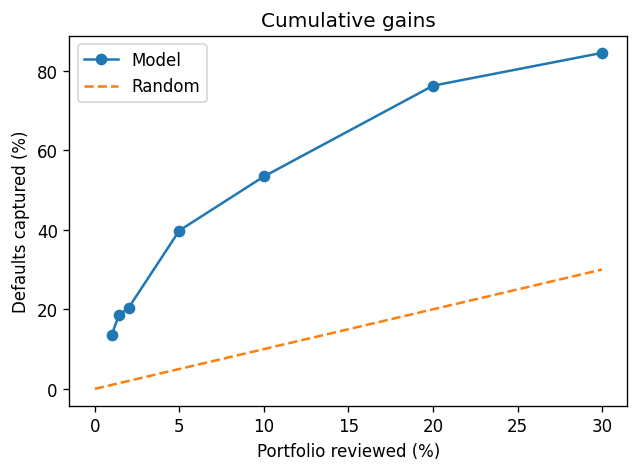

In [ ]:
plt.plot(
    gains_table['portfolio_fraction'] * 100,
    gains_table['capture'] * 100,
    marker='o',
    label='Model'
)

plt.plot(
    [0, 30],
    [0, 30],
    linestyle='--',
    label='Random'
)

plt.xlabel('Portfolio reviewed (%)')
plt.ylabel('Defaults captured (%)')
plt.legend()
plt.show()

The ranking is much stronger than the raw class prevalence suggests:

- Top 1% captures **13.6%** of all defaults.
- Top 1.42% captures **18.4%**.
- Top 5% captures **39.8%**.
- Top 10% captures **53.4%**.
- Top 20% captures **76.2%**.

At the top 5%, lift is about **8×** random targeting.

## 20. Risk deciles

In [ ]:
decile_table = pd.DataFrame({'decile': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'accounts': [1453, 1452, 1452, 1452, 1452, 1452, 1452, 1452, 1452, 1452], 'defaults': [110, 47, 17, 15, 7, 2, 2, 4, 1, 1], 'default_rate': [0.075705437026841, 0.0323691460055096, 0.0117079889807162, 0.0103305785123966, 0.0048209366391184, 0.0013774104683195, 0.0013774104683195, 0.0027548209366391, 0.0006887052341597, 0.0006887052341597], 'avg_score': [0.0851448296230373, 0.0368381398223753, 0.023507772149056, 0.0159471897386668, 0.0111974510206476, 0.0081043397126661, 0.0057716661253394, 0.0040084285671918, 0.0027530878864283, 0.0017224292445401], 'capture': [0.5339805825242718, 0.2281553398058252, 0.0825242718446602, 0.0728155339805825, 0.0339805825242718, 0.0097087378640776, 0.0097087378640776, 0.0194174757281553, 0.0048543689320388, 0.0048543689320388], 'cum_capture': [0.5339805825242718, 0.7621359223300971, 0.8446601941747572, 0.9174757281553396, 0.9514563106796116, 0.9611650485436892, 0.9708737864077668, 0.9902912621359222, 0.9951456310679612, 1.0]})
decile_table

 decile  accounts  defaults  default_rate  avg_score  capture  cum_capture
      1      1453       110      0.075705   0.085145 0.533981     0.533981
      2      1452        47      0.032369   0.036838 0.228155     0.762136
      3      1452        17      0.011708   0.023508 0.082524     0.844660
      4      1452        15      0.010331   0.015947 0.072816     0.917476
      5      1452         7      0.004821   0.011197 0.033981     0.951456
      6      1452         2      0.001377   0.008104 0.009709     0.961165
      7      1452         2      0.001377   0.005772 0.009709     0.970874
      8      1452         4      0.002755   0.004008 0.019417     0.990291
      9      1452         1      0.000689   0.002753 0.004854     0.995146
     10      1452         1      0.000689   0.001722 0.004854     1.000000

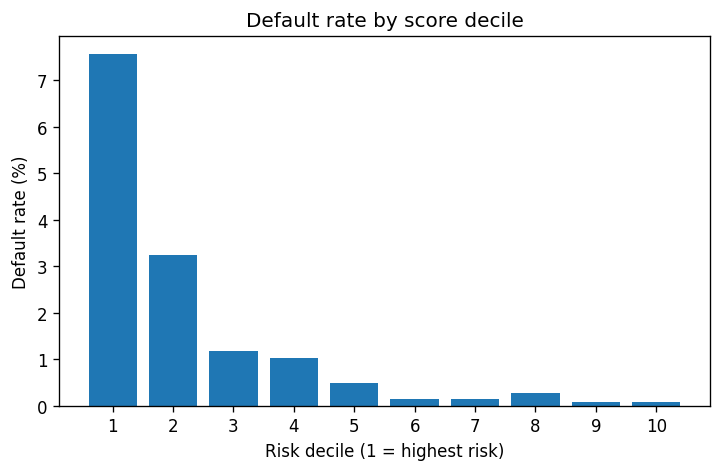

In [ ]:
plt.bar(
    decile_table['decile'].astype(str),
    decile_table['default_rate'] * 100
)
plt.xlabel('Risk decile (1 = highest risk)')
plt.ylabel('Default rate (%)')
plt.show()

The highest-risk decile has a default rate of about **7.57%**, compared with roughly **1.42%** in the overall portfolio. The model is concentrating default risk, even though the classes still overlap substantially.

## 21. Final model interpretation

In [ ]:
importance_table = pd.DataFrame({
    'feature':selected_features,
    'xgb1':final_xgb_1.feature_importances_,
    'xgb3':final_xgb_3.feature_importances_,
    'cat':final_cat.feature_importances_
})

for c in ['xgb1','xgb3','cat']:
    s = importance_table[c].sum()
    if s > 0:
        importance_table[c] /= s

importance_table['blend_importance'] = (
    .10 * importance_table['xgb1']
    + .25 * importance_table['xgb3']
    + .65 * importance_table['cat']
)

importance_table.sort_values(
    'blend_importance',
    ascending=False
).head(20)

                  feature     xgb1     xgb3      cat  blend_importance
        onus_attribute_26 0.140848 0.098410 0.021292          0.052527
         onus_attribute_2 0.029119 0.026704 0.058685          0.047733
               bureau_426 0.007452 0.007863 0.044855          0.031867
               bureau_441 0.009670 0.009159 0.033316          0.024912
        onus_attribute_35 0.012918 0.011148 0.029390          0.023183
                bureau_59 0.005303 0.005639 0.027962          0.020115
               bureau_428 0.003338 0.004094 0.027751          0.019395
               bureau_147 0.015730 0.010814 0.022589          0.018959
                bureau_51 0.004724 0.004970 0.025665          0.018397
        onus_attribute_11 0.005022 0.005019 0.023160          0.016811
               bureau_123 0.003264 0.003591 0.023067          0.016218
        onus_attribute_37 0.013574 0.011501 0.017568          0.015652
        onus_attribute_41 0.005631 0.010301 0.017462          0.014488
      

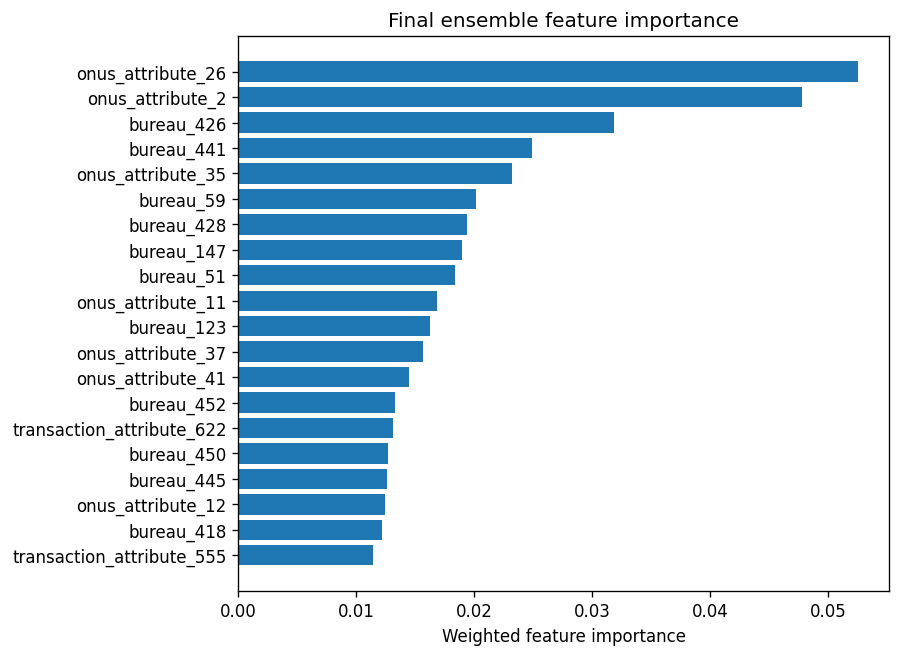

In [ ]:
importance_table.sort_values(
    'blend_importance'
).tail(20).plot(
    kind='barh',
    x='feature',
    y='blend_importance',
    legend=False
)
plt.xlabel('Weighted feature importance')
plt.show()

The model depends on a mixture of on-us, bureau and transaction attributes. Since the variables are anonymized, the interpretation is statistical rather than semantic.

## 22. Refit on all labelled accounts

The holdout evaluation is complete. Only now are all 96,806 labelled rows used for the final models that score the competition validation file.

In [ ]:
X_all = model_df[selected_features]
y_all = model_df['bad_flag']

production_xgb_1 = make_xgb(1.0)
production_xgb_3 = make_xgb(3.0)
production_cat = make_cat()

production_xgb_1.fit(X_all, y_all)
production_xgb_3.fit(X_all, y_all)
production_cat.fit(X_all, y_all)

## 23. Score the 41,792 unlabeled accounts

In [ ]:
score_df = pd.read_csv(
    SCORE_PATH,
    usecols=[
        'account_number'
    ] + selected_features,
    dtype={
        **{
            c:'float32'
            for c in selected_features
        },
        'account_number':'int64'
    }
)

In [ ]:
score_probability = (
    .10 * production_xgb_1.predict_proba(
        score_df[selected_features]
    )[:, 1]
    + .25 * production_xgb_3.predict_proba(
        score_df[selected_features]
    )[:, 1]
    + .65 * production_cat.predict_proba(
        score_df[selected_features]
    )[:, 1]
)

final_output = pd.DataFrame({
    'account_number':score_df['account_number'],
    'default_probability':score_probability
})

final_output.head()

 account_number  default_probability
         100001             0.029476
         100002             0.004253
         100003             0.004185
         100004             0.003208
         100005             0.024608

In [ ]:
final_output['default_probability'].describe()

count    41792.000000
mean         0.019586
std          0.030528
min          0.000610
25%          0.003833
50%          0.009212
75%          0.022836
max          0.601019

In [ ]:
OUTPUT_PATH = (
    DATA_DIR /
    'Final_output_optimized_v3.csv'
)

final_output.to_csv(
    OUTPUT_PATH,
    index=False
)

print(OUTPUT_PATH)

Final_output_optimized_v3.csv


No binary `0/1` prediction is submitted. The output is a continuous default-risk score. A bank can apply its own cost or capacity threshold.

## 24. Experiment log — kept vs rejected

In [ ]:
experiment_log = pd.DataFrame({'Experiment': ['PCA 90/95%', 'ANOVA', 'Mutual Information top 200', 'Random oversampling', 'Random undersampling', 'SMOTE', 'Borderline-SMOTE', 'ADASYN', 'Balanced Random Forest', 'EasyEnsemble', 'RUSBoost', 'XGBoost weight 1', 'XGBoost moderate weight', 'CatBoost', 'OOF weight search', 'Isotonic / Platt calibration'], 'Decision': ['Rejected', 'Kept as benchmark', 'Kept', 'Rejected', 'Rejected', 'Rejected as final', 'Rejected', 'Rejected', 'Rejected', 'Rejected', 'Rejected', 'Kept', 'Kept', 'Kept', 'Kept', 'Rejected for final'], 'Reason': ['Lower ranking performance than supervised/raw paths in the executed comparisons.', 'Strong statistical filter, but not the final representation.', 'Strong CatBoost/boosting path and used in final OOF stage.', 'Did not beat the strongest boosting path.', 'Lost majority-class information and did not improve final PR-AUC.', 'Mild ratios helped some runs, stronger ratios degraded ranking.', 'PR-AUC below the cost-sensitive boosting candidates.', 'Did not improve final ranking enough.', 'Lower PR-AUC.', 'Higher recall in places but weaker ranking/precision trade-off.', 'Substantially weaker ranking.', 'Good ranking and diversity.', 'Improved minority sensitivity without full rebalancing.', 'Strong complementary model in OOF ensemble.', 'Weights learned after predictions, not assumed.', 'No useful holdout improvement over raw score.']})
experiment_log

                  Experiment           Decision                                                                           Reason
                  PCA 90/95%           Rejected Lower ranking performance than supervised/raw paths in the executed comparisons.
                       ANOVA  Kept as benchmark                     Strong statistical filter, but not the final representation.
  Mutual Information top 200               Kept                       Strong CatBoost/boosting path and used in final OOF stage.
         Random oversampling           Rejected                                        Did not beat the strongest boosting path.
        Random undersampling           Rejected                Lost majority-class information and did not improve final PR-AUC.
                       SMOTE  Rejected as final                  Mild ratios helped some runs, stronger ratios degraded ranking.
            Borderline-SMOTE           Rejected                             PR-AUC below the cost

## 25. Why aggressive balancing did not win

The observed results are consistent with the imbalanced-learning literature:

- **SMOTE** creates synthetic minority points by interpolation; it can help, but it does not add new real default behaviour.
- In high-dimensional sparse data, nearest-neighbour interpolation can create synthetic samples that are not especially representative.
- **Cost-sensitive learning** changes the penalty for minority errors without discarding majority examples or synthesizing large numbers of points.
- Credit-scoring benchmarks show that no single imbalance treatment wins universally; resampling, synthetic generation, embedded methods and post-hoc adjustments need to be compared empirically.
- With severe imbalance, ROC-AUC alone can look optimistic, so PR-AUC and precision/recall curves are reported throughout.

### References

1. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). **SMOTE: Synthetic Minority Over-sampling Technique.** *Journal of Artificial Intelligence Research*, 16, 321–357. DOI: 10.1613/jair.953.
2. He, H., & Garcia, E. A. (2009). **Learning from Imbalanced Data.** *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284. DOI: 10.1109/TKDE.2008.239.
3. Saito, T., & Rehmsmeier, M. (2015). **The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets.** *PLOS ONE*, 10(3), e0118432. DOI: 10.1371/journal.pone.0118432.
4. Jiang, C., Lu, W., Wang, Z., & Ding, Y. (2023). **Benchmarking state-of-the-art imbalanced data learning approaches for credit scoring.** *Expert Systems with Applications*, 213, 118878. DOI: 10.1016/j.eswa.2022.118878.

## 25.1 Additional experiment — undersampling + sample weights

A final hybrid imbalance experiment combines **random undersampling** with **positive-row sample weights**. Nothing in the existing pipeline is replaced at this stage.

The experiment keeps the **MI top-200** representation fixed, undersamples only the training partition, leaves validation rows untouched, and then gives default rows a larger `sample_weight` during XGBoost fitting.

The grid tests RUS minority-to-majority ratios of **3%, 5%, 10% and 20%** with positive sample weights **1.5, 2, 3 and 5**. The purpose is to test whether reducing majority dominance and simultaneously increasing the loss contribution of defaults provides a better precision-recall trade-off than either technique alone.

In [ ]:
# Hybrid imbalance grid: undersampling + positive sample weights
hybrid_features = selected_features
hybrid_rows = []

def capture_at_fraction(y, score, frac):
    k = max(1, int(np.ceil(frac * len(score))))
    order = np.argsort(-score)[:k]
    return y.to_numpy()[order].sum() / y.sum()

for rus_ratio in [.03, .05, .10, .20]:
    rus = RandomUnderSampler(
        sampling_strategy=rus_ratio,
        random_state=42
    )

    X_rus, y_rus = rus.fit_resample(
        X_train[hybrid_features],
        y_train
    )

    for positive_weight in [1.5, 2.0, 3.0, 5.0]:
        row_weight = np.where(
            y_rus.to_numpy() == 1,
            positive_weight,
            1.0
        )

        hybrid_model = make_xgb(1.0)
        hybrid_model.fit(
            X_rus,
            y_rus,
            sample_weight=row_weight
        )

        hybrid_score = hybrid_model.predict_proba(
            X_tune[hybrid_features]
        )[:, 1]

        t = threshold_summary(
            y_tune,
            hybrid_score
        )

        hybrid_rows.append({
            'RUS_ratio':rus_ratio,
            'positive_sample_weight':positive_weight,
            'train_rows':len(X_rus),
            'train_default_rate':y_rus.mean(),
            'PR_AUC':average_precision_score(y_tune, hybrid_score),
            'ROC_AUC':roc_auc_score(y_tune, hybrid_score),
            'MaxF1':t['f1'],
            'F1_precision':t['p'],
            'F1_recall':t['r'],
            'Capture_1.42%':capture_at_fraction(y_tune, hybrid_score, .014173),
            'Capture_5%':capture_at_fraction(y_tune, hybrid_score, .05),
            'Capture_10%':capture_at_fraction(y_tune, hybrid_score, .10),
            'Capture_20%':capture_at_fraction(y_tune, hybrid_score, .20)
        })

hybrid_grid = pd.DataFrame(hybrid_rows)
hybrid_grid.sort_values(
    ['PR_AUC', 'MaxF1'],
    ascending=False
).head(8)

    RUS_ratio  positive_sample_weight  train_rows  train_default_rate   PR_AUC  ROC_AUC    MaxF1  F1_precision  F1_recall  Capture_1.42%  Capture_5%  Capture_10%  Capture_20%
7        0.05                     5.0       20160            0.047619 0.105204 0.805140 0.159292      0.146341   0.174757       0.145631    0.315534     0.441748     0.621359
4        0.05                     1.5       20160            0.047619 0.102543 0.804125 0.148649      0.138655   0.160194       0.131068    0.315534     0.451456     0.626214
0        0.03                     1.5       32960            0.029126 0.102392 0.805150 0.153374      0.112108   0.242718       0.131068    0.310680     0.461165     0.616505
2        0.03                     3.0       32960            0.029126 0.099643 0.804509 0.156682      0.149123   0.165049       0.140777    0.305825     0.456311     0.611650
6        0.05                     3.0       20160            0.047619 0.098519 0.801429 0.155378      0.131757   0.189320    

The single tuning split makes **RUS 5% + positive sample weight 5** look promising: PR-AUC rises to about **0.1052**, above the ordinary XGBoost baseline used in this comparison. Because the tuning set contains only 206 defaults, this result is not accepted immediately. The best hybrid setting is therefore subjected to the same **5-fold OOF check** used for final model selection.

In [ ]:
# OOF confirmation of the best hybrid setting
hybrid_oof_score = np.zeros(len(development_idx))
dev_local_hybrid = np.arange(len(development_idx))

for fold, (tr, va) in enumerate(
    cv.split(
        dev_local_hybrid,
        y_dev.to_numpy()
    )
):
    train_rows = development_idx[tr]
    valid_rows = development_idx[va]

    Xtr = model_df.loc[
        train_rows,
        selected_features
    ]
    ytr = model_df.loc[
        train_rows,
        'bad_flag'
    ]

    Xva = model_df.loc[
        valid_rows,
        selected_features
    ]

    rus = RandomUnderSampler(
        sampling_strategy=.05,
        random_state=42 + fold
    )
    X_rus, y_rus = rus.fit_resample(
        Xtr,
        ytr
    )

    row_weight = np.where(
        y_rus.to_numpy() == 1,
        5.0,
        1.0
    )

    hybrid_model = make_xgb(1.0)
    hybrid_model.fit(
        X_rus,
        y_rus,
        sample_weight=row_weight
    )

    hybrid_oof_score[va] = hybrid_model.predict_proba(
        Xva
    )[:, 1]

hybrid_oof_threshold = threshold_summary(
    y_dev,
    hybrid_oof_score
)
final_oof_threshold = threshold_summary(
    y_dev,
    oof_score
)

hybrid_oof_comparison = pd.DataFrame([
    {
        'Candidate':'RUS 5% + sample weight 5',
        'OOF_PR_AUC':average_precision_score(y_dev, hybrid_oof_score),
        'OOF_ROC_AUC':roc_auc_score(y_dev, hybrid_oof_score),
        'MaxF1':hybrid_oof_threshold['f1'],
        'Precision_at_MaxF1':hybrid_oof_threshold['p'],
        'Recall_at_MaxF1':hybrid_oof_threshold['r']
    },
    {
        'Candidate':'Selected 3-model OOF ensemble',
        'OOF_PR_AUC':average_precision_score(y_dev, oof_score),
        'OOF_ROC_AUC':roc_auc_score(y_dev, oof_score),
        'MaxF1':final_oof_threshold['f1'],
        'Precision_at_MaxF1':final_oof_threshold['p'],
        'Recall_at_MaxF1':final_oof_threshold['r']
    }
])

hybrid_oof_comparison

                        Candidate  OOF_PR_AUC  OOF_ROC_AUC    MaxF1  Precision_at_MaxF1  Recall_at_MaxF1
0           RUS 5% + sample weight 5    0.078605     0.819507 0.137201            0.126354          0.150086
1  Selected 3-model OOF ensemble       0.081507     0.825500 0.147921            0.109640          0.227273

**Decision — rejected for the final model.**

The hybrid strategy improves the **single tuning split** in PR-AUC, but the improvement does **not survive 5-fold OOF validation**. Its OOF PR-AUC is **0.0786** versus **0.0815** for the selected ensemble, OOF ROC-AUC is **0.8195** versus **0.8255**, and Max-F1 is **0.1372** versus **0.1479**. Recall at the Max-F1 point also falls from **22.7%** to **15.0%**.

Therefore the result is treated as tuning-split optimism rather than a robust gain. The locked holdout is not used to rescue this candidate, and the existing final model remains unchanged: **10% XGBoost (weight 1) + 25% XGBoost (weight 3) + 65% CatBoost**.

## 26. Final takeaways

1. The low event prevalence means accuracy is misleading and precision is inherently difficult.
2. EDA shows real univariate signal, especially in on-us and bureau-related variables, but no single raw feature separates the classes completely.
3. PCA was tested and rejected rather than assumed to be inferior.
4. Aggressive oversampling/undersampling did not solve the problem; moderate cost sensitivity performed better.
5. OOF validation was required because a 15% tuning split contains only about 206 defaults.
6. Ensemble weights were learned from OOF predictions after the individual models were trained.
7. The final model improves the old project's recall/F1 trade-off while also lifting ROC-AUC substantially.
8. The submitted object is a probability score; threshold choice is an operational decision layer.